In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv('BostonHousing.csv')

In [5]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (506, 14)
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [7]:
X = df.drop('medv', axis=1)
y = df['medv']

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("First 5 rows of scaled data:")
print(X[:5])

First 5 rows of scaled data:
[[-0.41978194  0.28482986 -1.2879095  -0.27259857 -0.14421743  0.41235069
  -0.12001342  0.1402136  -0.98284286 -0.66660821 -1.45900038  0.44105193
  -1.0755623 ]
 [-0.41733926 -0.48772236 -0.59338101 -0.27259857 -0.74026221  0.19387449
   0.36716642  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.44105193
  -0.49243937]
 [-0.41734159 -0.48772236 -0.59338101 -0.27259857 -0.74026221  1.27774347
  -0.26581176  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.39642699
  -1.2087274 ]
 [-0.41675042 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.01245093
  -0.80988851  1.07773662 -0.75292215 -1.10611514  0.1130321   0.41616284
  -1.36151682]
 [-0.41248185 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.22383375
  -0.51117971  1.07773662 -0.75292215 -1.10611514  0.1130321   0.44105193
  -1.02650148]]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (354, 13) (354,)
Testing set shape: (152, 13) (152,)


In [11]:
model = Sequential()
model.add(Dense(64, input_dim=13, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

print(model.summary())


C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['mean_absolute_error']
)

In [15]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 621.3005 - mean_absolute_error: 23.0492 - val_loss: 585.0096 - val_mean_absolute_error: 22.7014
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 612.3756 - mean_absolute_error: 22.7189 - val_loss: 582.9196 - val_mean_absolute_error: 22.6553
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 647.9811 - mean_absolute_error: 23.4090 - val_loss: 580.7670 - val_mean_absolute_error: 22.6077
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 657.2629 - mean_absolute_error: 23.5371 - val_loss: 578.5586 - val_mean_absolute_error: 22.5588
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 610.6130 - mean_absolute_error: 22.9718 - val_loss: 576.2679 - val_mean_absolute_error: 22.5080
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 592.4907 - mean_absolute_error: 22.4701 - val_loss: 573.8784 - val_mean_absolute_error: 22.4549
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 624.5692 - mean_ab

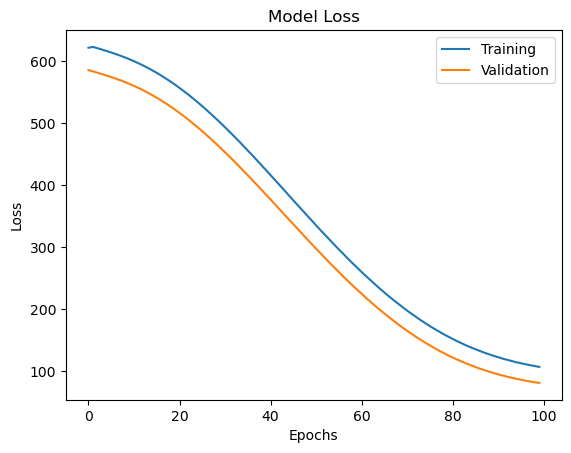

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()

In [19]:
loss, mae = model.evaluate(X_test, y_test)
print('Mean Absolute Error:', mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 73.2786 - mean_absolute_error: 5.7659
Mean Absolute Error: 5.969383239746094
